# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
url='https://drive.google.com/uc?id=1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma&export=download'

output='regression.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma&export=download
To: /home/mirshod/Desktop/DSB10_Intro_to_ML.ID_886521-1/src/ex05/regression.csv
100%|██████████| 715/715 [00:00<00:00, 3.94MB/s]


'regression.csv'

In [3]:
df=pd.read_csv(f'{output}')
df.drop('pageviews', inplace=True, axis=1)
df.head()

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


In [4]:
df['uid']=df['uid'].str.removeprefix('user_')
df.head()

,uid,num_commits,AVG(diff)
0,1,62,-64.400000
1,10,20,-74.800000
2,14,61,-159.000000
3,17,51,-61.600000
4,18,5,-5.666667


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [5]:
kmeans=KMeans(n_clusters=5, random_state=21)
kmeans.fit(df)

KMeans(n_clusters=5, random_state=21)

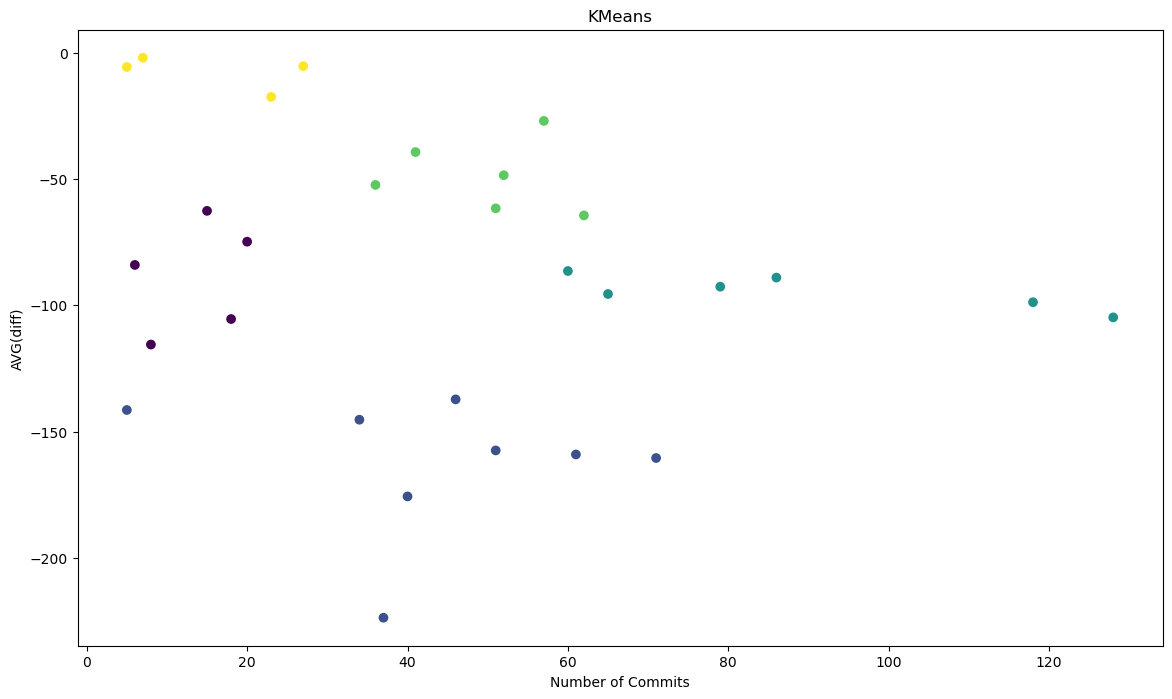

In [6]:
plt.figure(figsize=(14, 8))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=kmeans.labels_)
plt.xlabel('Number of Commits')
plt.ylabel('AVG(diff)')
plt.title('KMeans')
plt.show()

In [7]:
predicted=kmeans.predict(df)
sil_score=silhouette_score(df, predicted)
print(f'Silhouette Score: {sil_score}')

Silhouette Score: 0.4458207839622442


## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [8]:
dbscan=DBSCAN(eps=20, min_samples=2)
dbscan.fit(df)

DBSCAN(eps=20, min_samples=2)

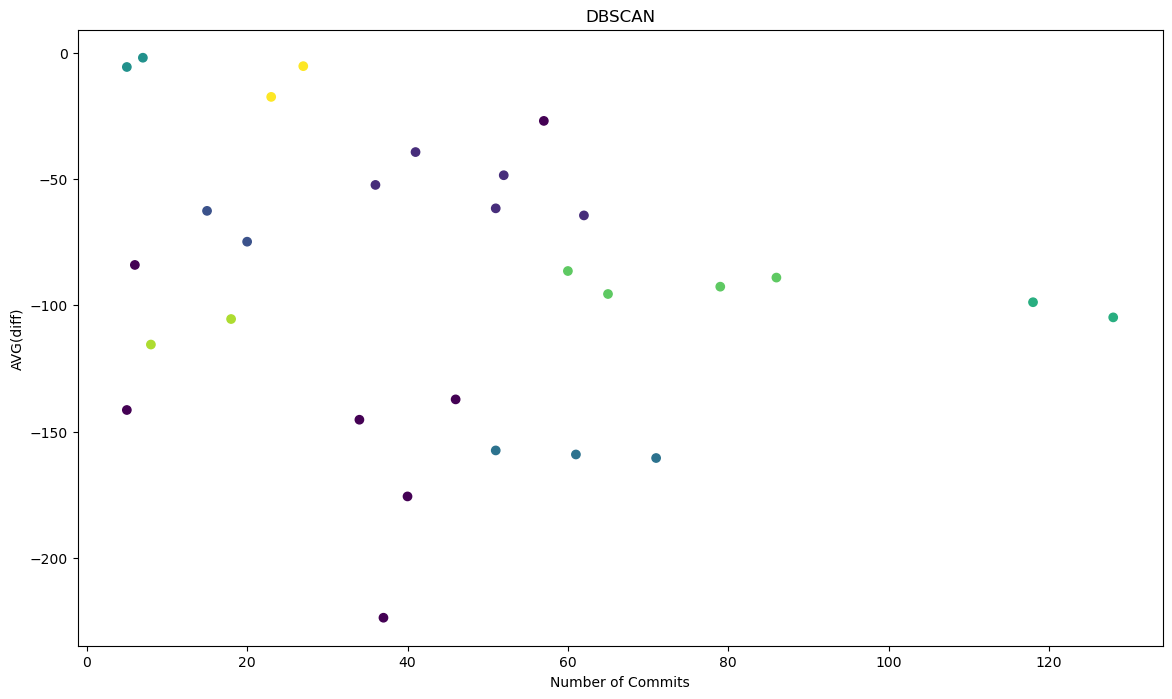

In [9]:
plt.figure(figsize=(14, 8))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=dbscan.labels_)
plt.xlabel('Number of Commits')
plt.ylabel('AVG(diff)')
plt.title('DBSCAN')
plt.show()

In [10]:
predicted=dbscan.labels_
sil_score=silhouette_score(df, predicted)
print(f'Silhouette Score: {sil_score}')

Silhouette Score: 0.2758905593871803


## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [11]:
agg_cls=AgglomerativeClustering(n_clusters=8)
agg_cls.fit(df)

AgglomerativeClustering(n_clusters=8)

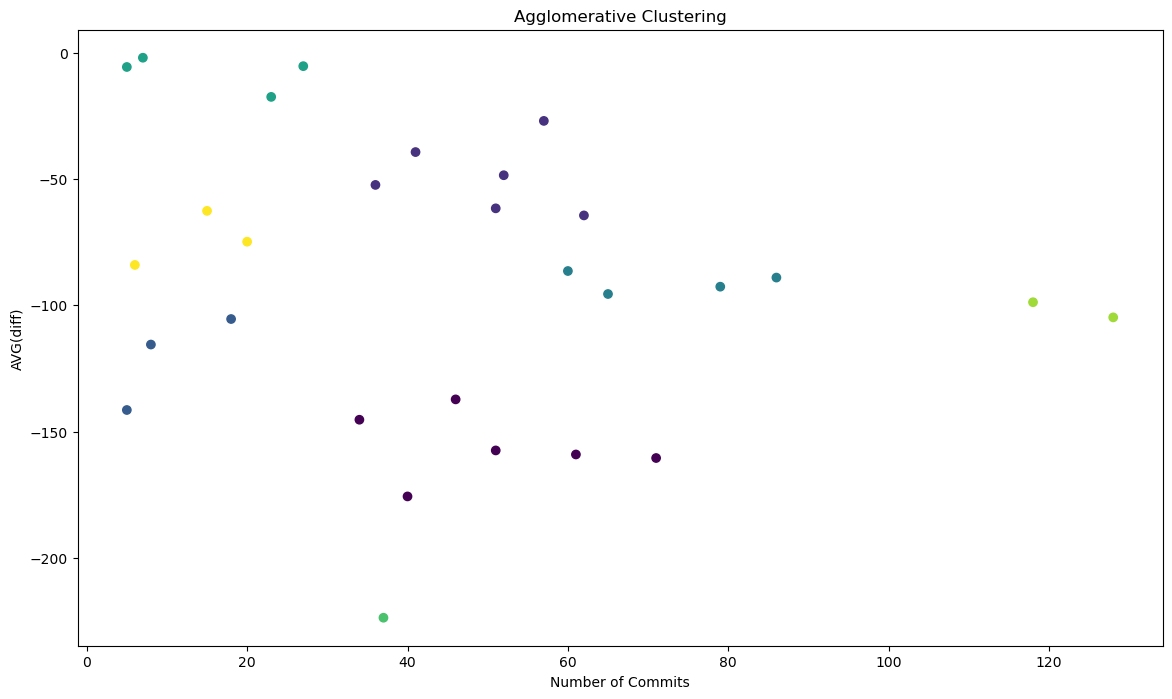

In [12]:
plt.figure(figsize=(14, 8))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=agg_cls.labels_)
plt.xlabel('Number of Commits')
plt.ylabel('AVG(diff)')
plt.title('Agglomerative Clustering')
plt.show()

In [13]:
predicted=agg_cls.labels_
sil_score=silhouette_score(df, predicted)
print(f'Silhouette Score: {sil_score}')

Silhouette Score: 0.4576745950207177


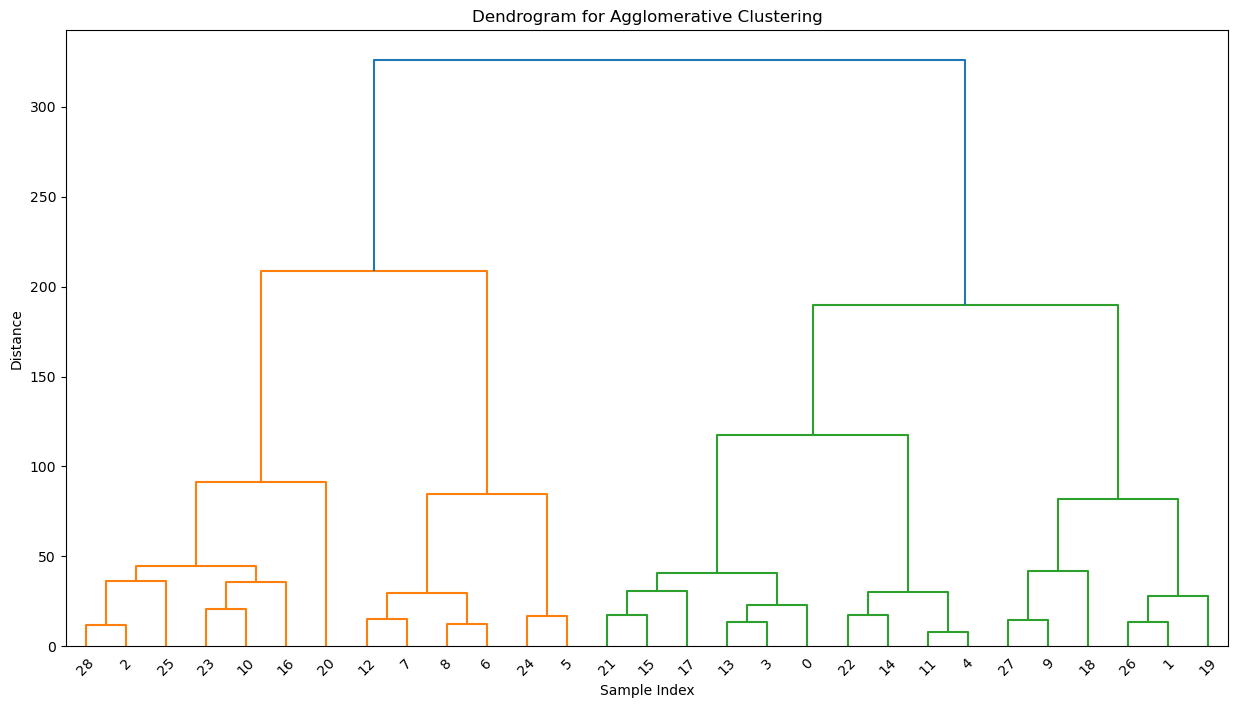

In [14]:

linked = linkage(df, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [ ]:
def silhouete_exp(model, param_name, param_values):
  sil_scores = []
  for value in param_values:
    
    model_instance = model.__class__(**model.get_params())
    model_instance.set_params(**{param_name: value})
    model_instance.fit(df)
    predicted = model_instance.labels_ if hasattr(model_instance, 'labels_') else model_instance.predict(df)
    
    if len(np.unique(predicted)) > 1:
        sil_score = silhouette_score(df, predicted)
    else:
        sil_score = -1
    sil_scores.append(sil_score)

  best_score_index = np.argmax(sil_scores)
  best_param_value = param_values[best_score_index]
  print(f"Best Silhouette Score: {sil_scores[best_score_index]:.4f} for {param_name}={best_param_value}")

  fig, axes = plt.subplots(1, 2, figsize=(20, 8))

  # Silhouette score vs. parameter value
  axes[0].plot(param_values, sil_scores, marker='o')
  axes[0].set_xlabel(f'{param_name.replace("_", " ").title()}')
  axes[0].set_ylabel('Silhouette Score')
  axes[0].set_title(f'Silhouette Score vs. {param_name.replace("_", " ").title()}')
  axes[0].axvline(x=best_param_value, color='r', linestyle='--', label=f'Best {param_name.replace("_", " ").title()}: {best_param_value}')
  axes[0].legend()
  axes[0].grid(True)

  # Visualization of clustering with best parameter value
  best_model = model.__class__(**model.get_params())
  best_model.set_params(**{param_name: best_param_value})
  best_model.fit(df)
  predicted_best = best_model.labels_ if hasattr(best_model, 'labels_') else best_model.predict(df)

  axes[1].scatter(df['num_commits'], df['AVG(diff)'], c=predicted_best)
  axes[1].set_xlabel('Number of Commits')
  axes[1].set_ylabel('AVG(diff)')
  axes[1].set_title(f'Clustering with Best {param_name.replace("_", " ").title()} ({best_param_value})')
  plt.tight_layout()
  plt.show()

Best Silhouette Score: 0.4327 for n_clusters=8


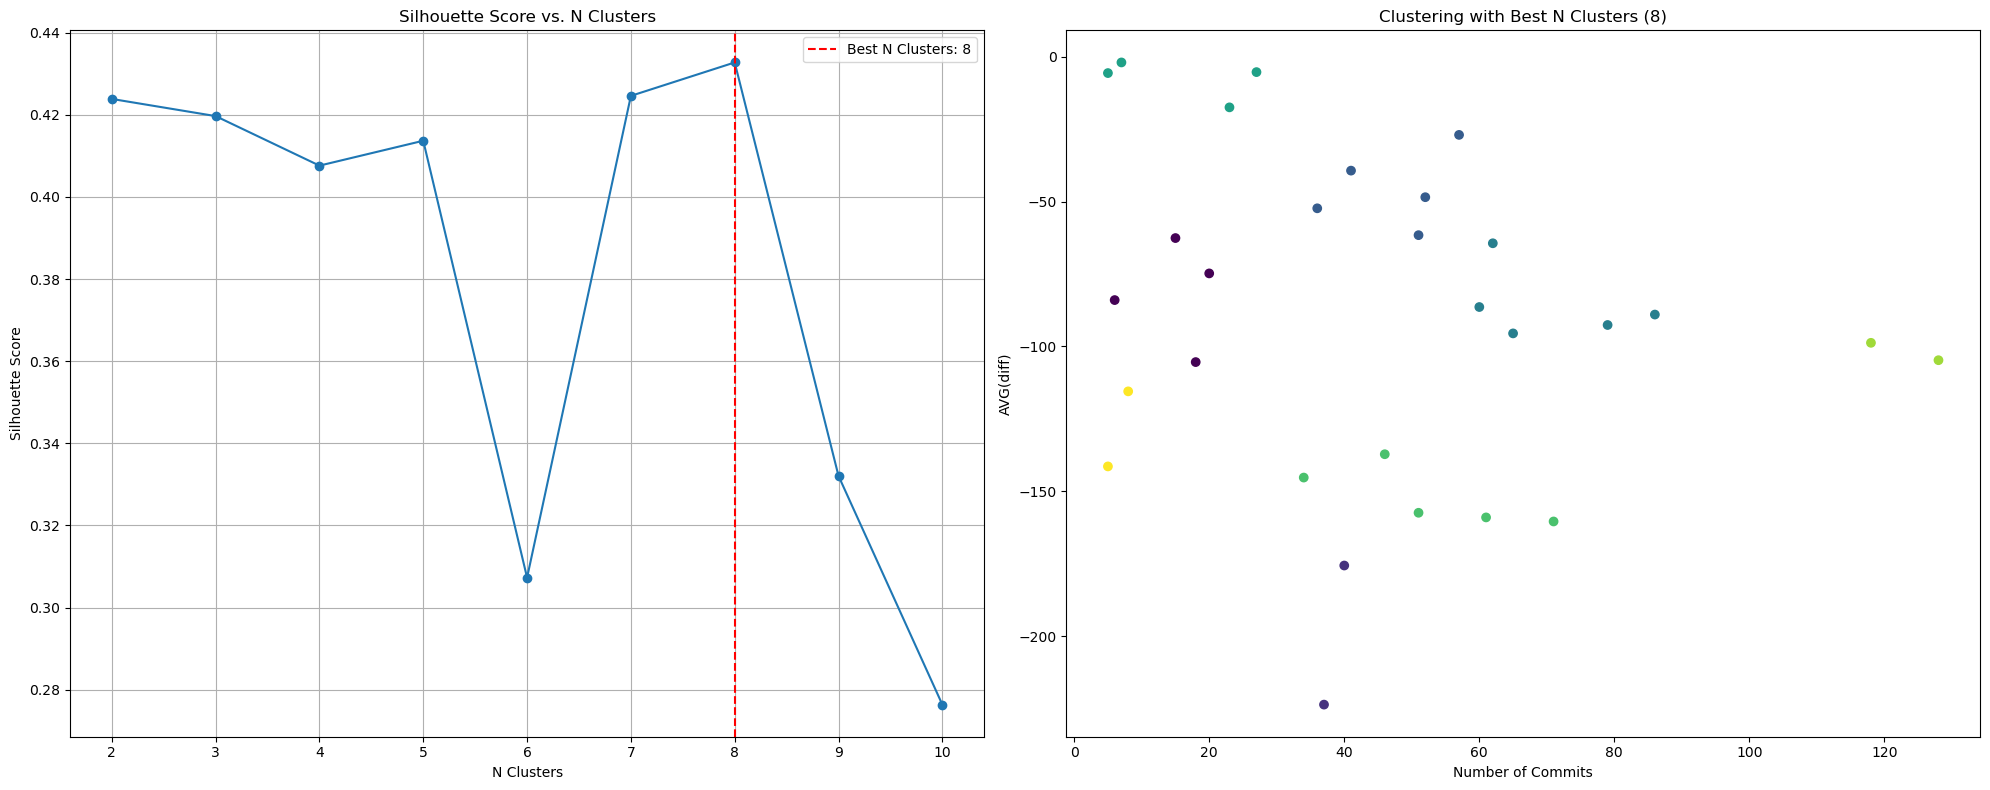

In [16]:
silhouete_exp(KMeans(), 'n_clusters', [2, 3, 4, 5, 6, 7, 8, 9, 10])

Best Silhouette Score: 0.3595 for eps=50


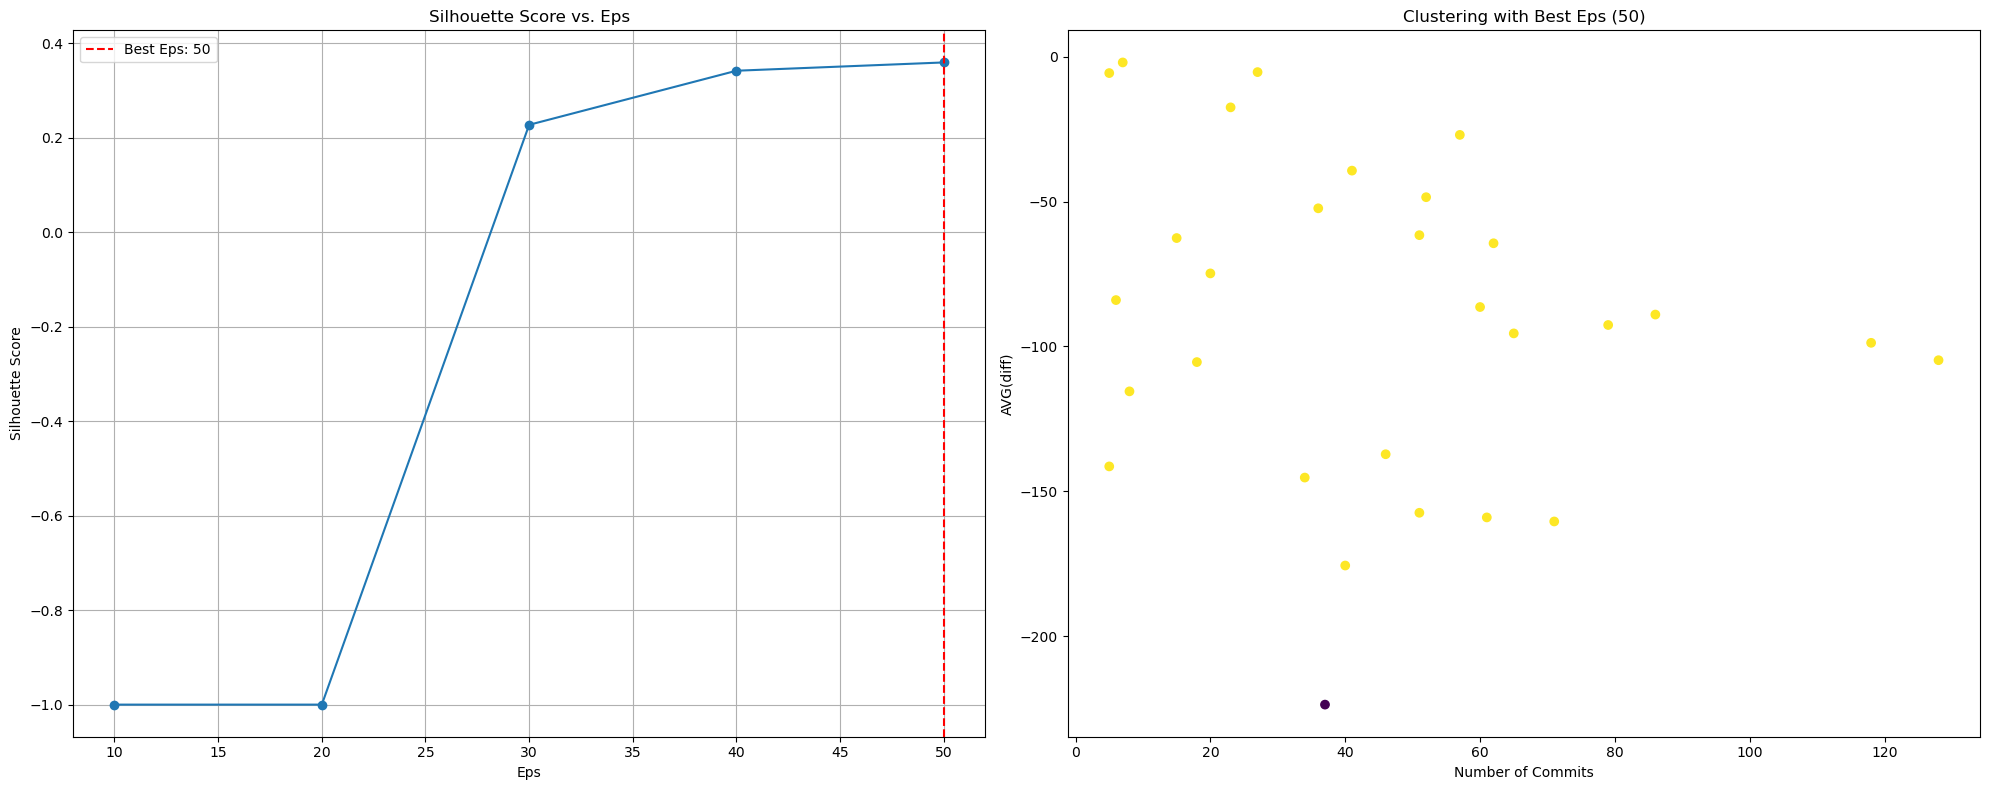

In [17]:
silhouete_exp(DBSCAN(), 'eps', [10, 20, 30, 40, 50])

Best Silhouette Score: 0.4577 for n_clusters=8


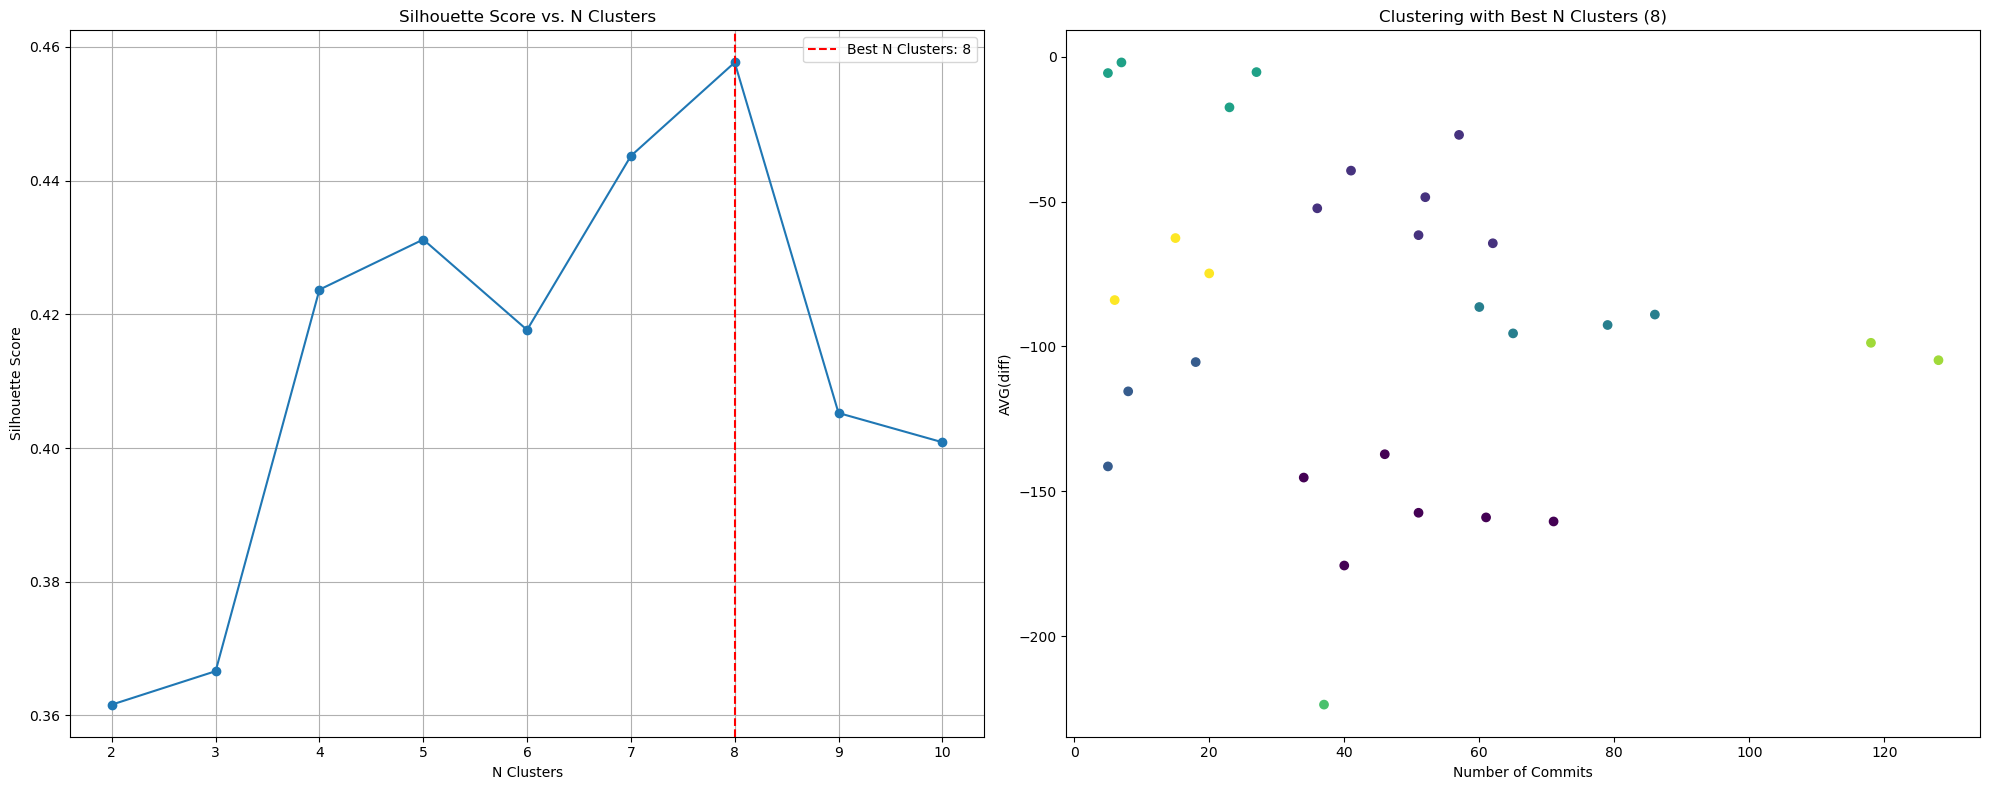

In [18]:
silhouete_exp(AgglomerativeClustering(), 'n_clusters', [2, 3, 4, 5, 6, 7, 8, 9, 10])